# Deliverable 2 — LR Binary Track (Benign vs Attack)

This notebook implements:

- Collapse all attack families into **Attack** (Benign vs Attack).
- Retrain Logistic Regression.
- Plot the **Precision-Recall curve** on **validation**.
- Pick a decision **threshold** and report precision/recall at that threshold.


In [16]:
import json, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    classification_report
)

ROOT = "/kaggle/input/datasets/kashyap1264/synthetic-data/synthetic_ipv6_grounded_v3_32x32"
OUT_DIR = Path("results"); OUT_DIR.mkdir(exist_ok=True, parents=True)


DROP_COLS = ["record_id","window_start_utc","window_end_utc","src_ip","dst_ip"]
TARGET = "label"


In [17]:
flows = pd.read_csv(f"{ROOT}/flows.csv")
train_split = pd.read_csv(f"{ROOT}/train.csv")
val_split   = pd.read_csv(f"{ROOT}/val.csv")
test_split  = pd.read_csv(f"{ROOT}/test.csv")


train = flows.merge(train_split[["record_id"]], on="record_id", how="inner")
val   = flows.merge(val_split[["record_id"]],   on="record_id", how="inner")
test  = flows.merge(test_split[["record_id"]],  on="record_id", how="inner")

print("Rows:", {"train": len(train), "val": len(val), "test": len(test)})


Rows: {'train': 2100, 'val': 450, 'test': 450}


In [18]:
def split_xy(df):
    X = df.drop(columns=[TARGET] + DROP_COLS, errors="ignore")
    y = df[TARGET].astype(str).values
    return X, y

def to_binary(y):
    y = pd.Series(y).astype(str)
    return np.where(y=="Benign", "Benign", "Attack")

def plot_pr(prec, rec, mark_idx, title, outpath):
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    if mark_idx is not None:
        plt.scatter(rec[mark_idx], prec[mark_idx])
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()

X_train, y_train = split_xy(train)
X_val, y_val = split_xy(val)
X_test, y_test = split_xy(test)

y_train_b = to_binary(y_train)
y_val_b   = to_binary(y_val)
y_test_b  = to_binary(y_test)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler(with_mean=False))]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
], remainder="drop")

clf = LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced", random_state=11)
pipe = Pipeline([("prep", preprocess), ("clf", clf)])
pipe.fit(X_train, y_train_b)

print("Classes order:", pipe.named_steps["clf"].classes_)


Classes order: ['Attack' 'Benign']


Chosen threshold (val, max F1): 0.9257775546068464
Val average precision: 0.787051484356342
Val precision/recall/f1: 0.8095238095238095 0.6538461538461539 0.7234042553186545


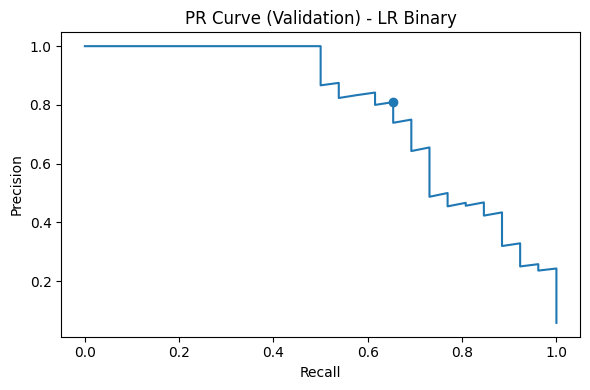

In [19]:
# Validation PR curve + threshold selection (max F1)
y_val_true = (y_val_b=="Attack").astype(int)
scores_val = pipe.predict_proba(X_val)[:, 0]  # Attack prob (classes: [Attack, Benign])

prec, rec, thr = precision_recall_curve(y_val_true, scores_val)
f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
best_i = int(np.argmax(f1))
best_thr = float(thr[best_i])

print("Chosen threshold (val, max F1):", best_thr)
print("Val average precision:", average_precision_score(y_val_true, scores_val))
print("Val precision/recall/f1:", float(prec[best_i]), float(rec[best_i]), float(f1[best_i]))

plot_pr(prec, rec, best_i, "PR Curve (Validation) - LR Binary", OUT_DIR/"pr_curve_val.png")


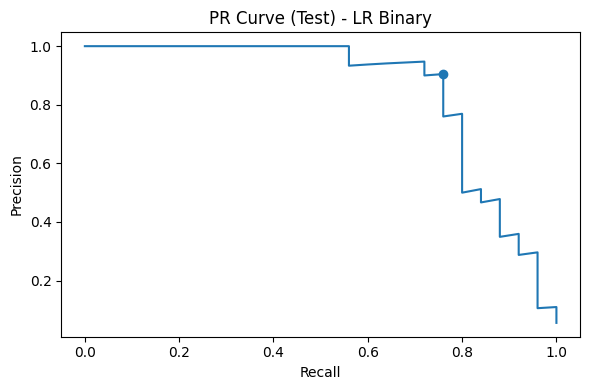

Test precision/recall/f1: 0.9047619047619048 0.76 0.8260869565217391
Confusion matrix [[TN, FP],[FN, TP]]:
[[423   2]
 [  6  19]]

Test classification report:
              precision    recall  f1-score   support

      Benign     0.9860    0.9953    0.9906       425
      Attack     0.9048    0.7600    0.8261        25

    accuracy                         0.9822       450
   macro avg     0.9454    0.8776    0.9084       450
weighted avg     0.9815    0.9822    0.9815       450

Saved to: /kaggle/working/results


In [20]:
# Test PR curve (reference) + evaluation at chosen threshold
y_test_true = (y_test_b=="Attack").astype(int)
scores_test = pipe.predict_proba(X_test)[:, 0]

prec_t, rec_t, thr_t = precision_recall_curve(y_test_true, scores_test)
mark = None
if len(thr_t) > 0:
    mark = int(np.argmin(np.abs(thr_t - best_thr)))
plot_pr(prec_t, rec_t, mark, "PR Curve (Test) - LR Binary", OUT_DIR/"pr_curve_test.png")

pred_test = (scores_test >= best_thr).astype(int)

p = precision_score(y_test_true, pred_test, zero_division=0)
r = recall_score(y_test_true, pred_test, zero_division=0)
f = f1_score(y_test_true, pred_test, zero_division=0)
cm = confusion_matrix(y_test_true, pred_test, labels=[0,1])

print("Test precision/recall/f1:", float(p), float(r), float(f))
print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm)

print("\nTest classification report:")
print(classification_report(y_test_true, pred_test, target_names=["Benign","Attack"], digits=4, zero_division=0))

out = {
    "threshold_selected_on": "validation",
    "selection_rule": "max_f1_on_pr_curve",
    "threshold": best_thr,
    "test_average_precision": float(average_precision_score(y_test_true, scores_test)),
    "test_precision_attack": float(p),
    "test_recall_attack": float(r),
    "test_f1_attack": float(f),
    "confusion_matrix": {"TN": int(cm[0,0]), "FP": int(cm[0,1]), "FN": int(cm[1,0]), "TP": int(cm[1,1])},
}
(OUT_DIR/"lr_binary_pr_threshold_metrics.json").write_text(json.dumps(out, indent=2))
(OUT_DIR/"lr_binary_classification_report_test.txt").write_text(
    classification_report(y_test_true, pred_test, target_names=["Benign","Attack"], digits=4, zero_division=0)
)
pd.DataFrame(cm, index=["Benign_true","Attack_true"], columns=["Benign_pred","Attack_pred"]).to_csv(
    OUT_DIR/"lr_binary_confusion_matrix_test.csv"
)

print("Saved to:", OUT_DIR.resolve())
